<a href="https://colab.research.google.com/github/samriddhisingh05/1BM23CS295_Samriddhi_Singh_ML_Lab/blob/main/1BM23CS295_Lab_7_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [5]:
# Load dataset
data = pd.read_csv("iris.csv")

# Display first few rows
print(data.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [6]:

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)

rf_default.fit(X_train, y_train)


y_pred = rf_default.predict(X_test)


default_score = accuracy_score(y_test, y_pred)

print("Accuracy with default (10 trees):", default_score)

Accuracy with default (10 trees): 1.0


In [8]:
best_score = 0
best_n = 0

for n in [10, 20, 50, 100, 150, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    print(f"n_estimators = {n}, Accuracy = {score}")

    if score > best_score:
        best_score = score
        best_n = n

print("\nBest Score:", best_score)
print("Best Number of Trees:", best_n)

n_estimators = 10, Accuracy = 1.0
n_estimators = 20, Accuracy = 1.0
n_estimators = 50, Accuracy = 1.0
n_estimators = 100, Accuracy = 1.0
n_estimators = 150, Accuracy = 1.0
n_estimators = 200, Accuracy = 1.0

Best Score: 1.0
Best Number of Trees: 10


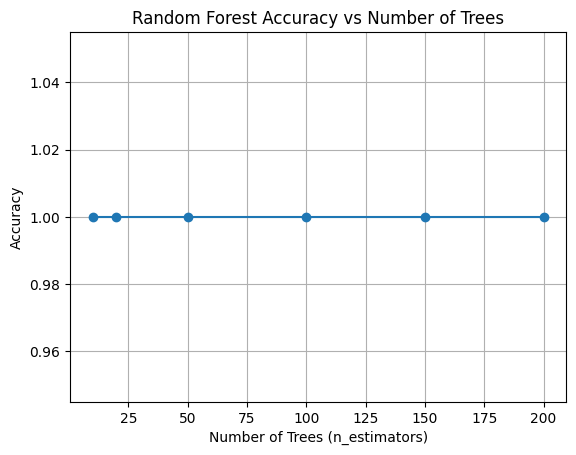

In [9]:
import matplotlib.pyplot as plt


n_values = [10, 20, 50, 100, 150, 200]
scores = []

for n in n_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    scores.append(score)

# Plot graph
plt.figure()
plt.plot(n_values, scores, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid()

plt.show()